In [98]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_validate

In [99]:
# 주택 가격 예측 모델
'''
문6-11> 데이터셋을 불러오고, 아래 항목을 확인하시오.
- 상위 5개 항목 출력
- 데이터의 주요 통계 지표 확인
'''

# 데이터 탐색
df = pd.read_csv('exercise4.csv', index_col=None)
df.head()

,평균 주택 면적,교통 편의지수,교육 점수,인구 밀집도,평균 주택 가격
0,83.910,16.0,67.021277,31.346578,34.8
1,88.920,24.0,55.319149,38.714128,36.6
2,95.925,96.0,80.851064,31.843267,43.4
3,100.170,16.0,36.170213,12.527594,57.2
4,92.430,8.0,22.340426,15.728477,48.2


In [100]:
'''
총 5개의 컬럼을 가지고 있는 데이터로, 마지막 컬럼인 '평균 주택 가격'이 타겟 변수로 사용할 값이다. 나머지 컬럼은 '평균 주택 가격'을 예측하는데 사용할 수 있는 피처로 '평균 주택 면적', '교통 편의 지수', '교육 점수', '인구 밀집도'의 4개의 속성이 존재한다.
'''

"\n총 5개의 컬럼을 가지고 있는 데이터로, 마지막 컬럼인 '평균 주택 가격'이 타겟 변수로 사용할 값이다. 나머지 컬럼은 '평균 주택 가격'을 예측하는데 사용할 수 있는 피처로 '평균 주택 면적', '교통 편의 지수', '교육 점수', '인구 밀집도'의 4개의 속성이 존재한다.\n"

In [101]:
df.describe()

,평균 주택 면적,교통 편의지수,교육 점수,인구 밀집도,평균 주택 가격
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,94.228740,37.976000,62.238298,30.096302,45.058000
std,10.544196,34.710359,23.038239,19.632020,18.237724
min,53.415000,4.000000,0.000000,0.000000,10.000000
25%,88.245000,16.000000,50.797872,14.514349,34.200000
50%,93.127500,20.000000,68.085106,26.572848,42.400000
75%,99.307500,96.000000,80.851064,41.901214,50.000000
max,131.700000,96.000000,100.000000,100.000000,100.000000


In [102]:
'''
모든 컬럼은 500개의 인스턴스를 포함하고 있다. 평균 주택 면적은 약 53~132의 값이 존재한다. 교통 편의지수, 교육점수, 인구 밀집도는 대략 0에서 100사이의 값으로 분포한다. 평균 주택 가격은 10부터 100사이의 값이 존재한다.
'''

'\n모든 컬럼은 500개의 인스턴스를 포함하고 있다. 평균 주택 면적은 약 53~132의 값이 존재한다. 교통 편의지수, 교육점수, 인구 밀집도는 대략 0에서 100사이의 값으로 분포한다. 평균 주택 가격은 10부터 100사이의 값이 존재한다.\n'

"\n'평균 주택 가격'의 분포는 10에서 100사이의 값이 분포하고 있다. 대부분의 값이 40~50 사이에 있다. '평균 주택 면적'의 경우 종 모양의 정규분포를 띄는 히스토그램이 그려진 반면, 한 쪽으로 치우치거나, 값이 고르게 분포하지 않는 데이터 분포도 보이고 있다.\n"

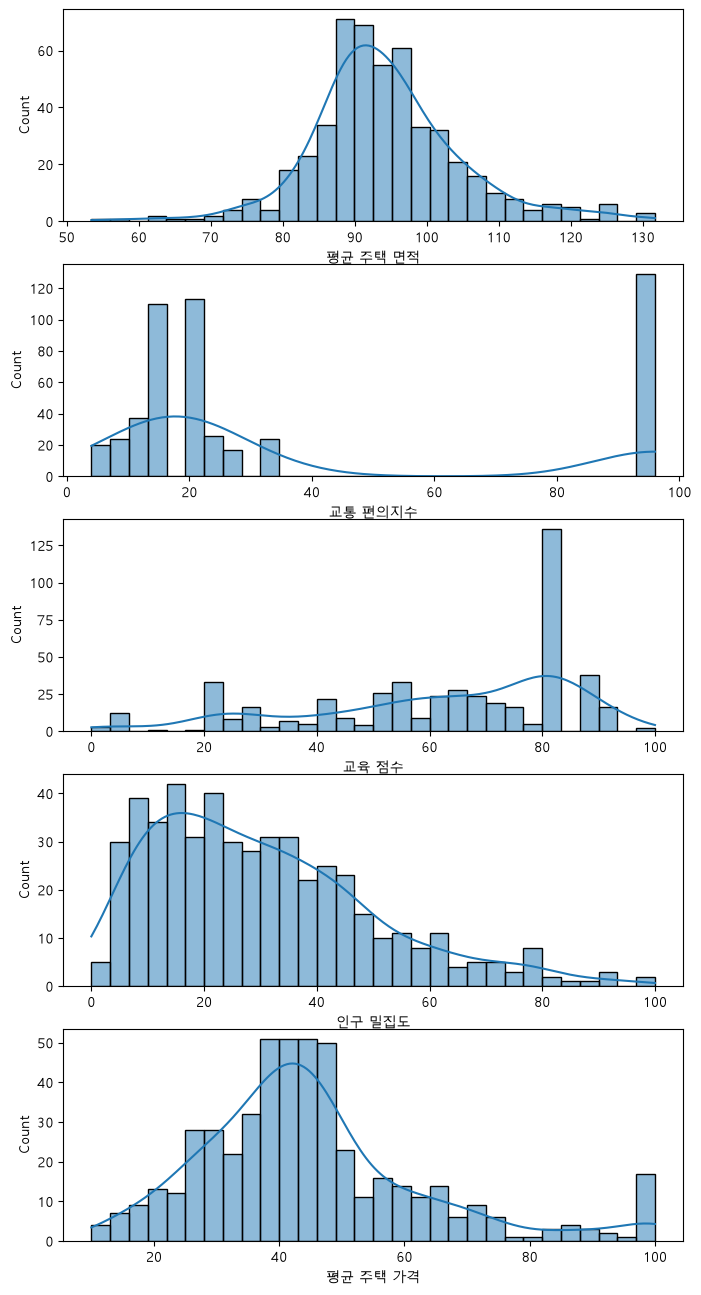

In [103]:
'''
문6-12> 각 특성의 데이터 분포 확인하기 위해 시각화하시오.
- 시각화 방법: 히스토그램(kde=True, bins=30)
- 5개의 속성을 각각 표시하도록 서브플롯(subplot)을 생성
'''

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 기호 표시
plt.rcParams['axes.unicode_minus'] = False

nrows = 5
ncols = 1
fig, axs = plt.subplots(nrows, ncols)
fig.set_size_inches(8, 16)

# 데이터 분포 확인 - 히스토그램
for i in range(len(df.columns)):
    sns.histplot(x=df.columns[i], data=df, kde=True, bins=30, ax=axs[i])

'''
'평균 주택 가격'의 분포는 10에서 100사이의 값이 분포하고 있다. 대부분의 값이 40~50 사이에 있다. '평균 주택 면적'의 경우 종 모양의 정규분포를 띄는 히스토그램이 그려진 반면, 한 쪽으로 치우치거나, 값이 고르게 분포하지 않는 데이터 분포도 보이고 있다.
'''

"\n'평균 주택 면적'이 증가할수록 '평균 주택 가격'은 증가하고 있는 형태의 산점도를 확인할 수 있다. 이는 두 개의 변수는 서로 양의 상관관계를 보이고 있다고 해석할 수 있다. 반면에 '인구 밀집도'는 증가할 수록 '평균 주택 가격'은 감소하는 형태를 띄고 있다. 이 두 변수는 서로 음의 상관관계를 보이고 있다고 해석할 수 있다.\n\n따라서 '평균 주택 가격'와 가장 상관관계가 높은 속성은 '평균 주택 면적'이다.\n"

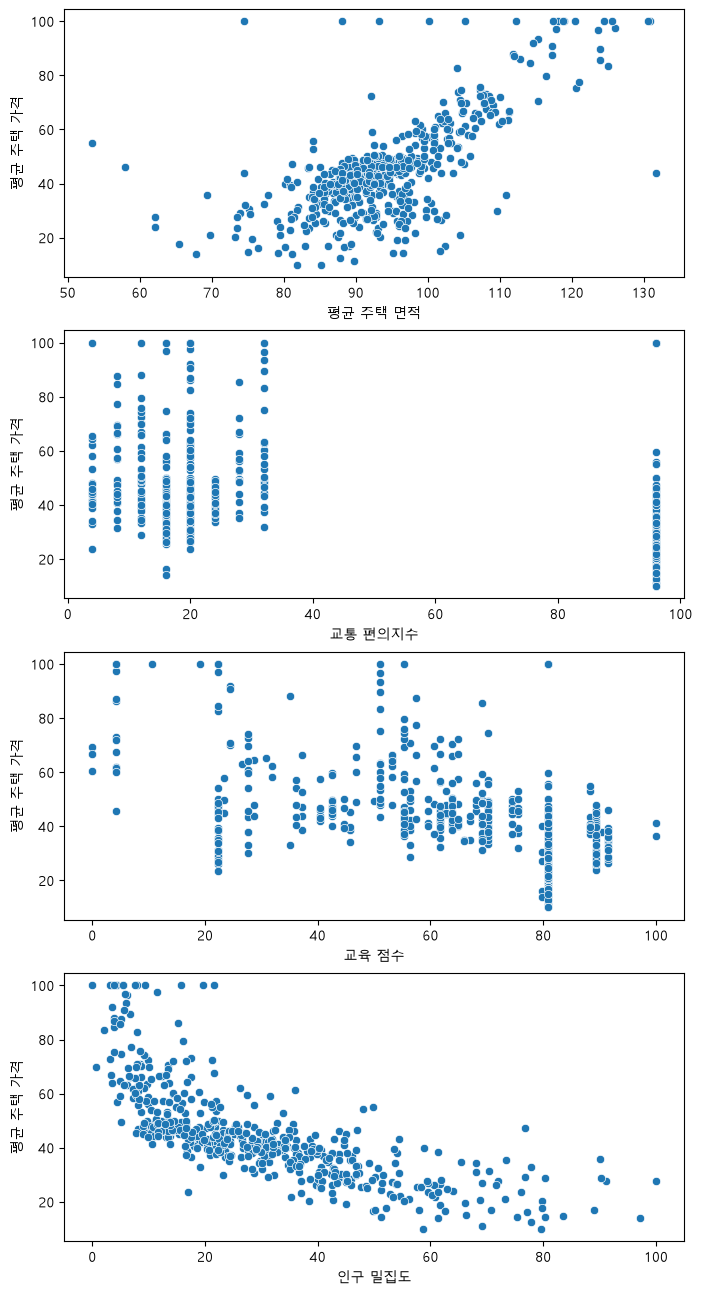

In [104]:
'''
문6-13> '평균 주택 가격'과 가장 상관관계가 높은 속성을 확인하시오.
'''
# 방법1 - 데이터 시각화로 상관관계를 확인하기
# 데이터 분포 확인 - 산점도
nrows = 4
ncols = 1

fig, axs = plt.subplots(nrows, ncols)
fig.set_size_inches(8, 16)

for i in range(len(df.columns) - 1):
    sns.scatterplot(x=df.columns[i], y='평균 주택 가격', data=df, ax=axs[i])

'''
'평균 주택 면적'이 증가할수록 '평균 주택 가격'은 증가하고 있는 형태의 산점도를 확인할 수 있다. 이는 두 개의 변수는 서로 양의 상관관계를 보이고 있다고 해석할 수 있다. 반면에 '인구 밀집도'는 증가할 수록 '평균 주택 가격'은 감소하는 형태를 띄고 있다. 이 두 변수는 서로 음의 상관관계를 보이고 있다고 해석할 수 있다.

따라서 '평균 주택 가격'와 가장 상관관계가 높은 속성은 '평균 주택 면적'이다.
'''

In [105]:
# 방법2 - 상관계수로 상관관계를 확인하기
# 데이터 분포 확인 - 변수 간 상관관계
df.corr()

,평균 주택 면적,교통 편의지수,교육 점수,인구 밀집도,평균 주택 가격
평균 주택 면적,1.000000,-0.209952,-0.350765,-0.616391,0.694622
교통 편의지수,-0.209952,1.000000,0.462282,0.481111,-0.374742
교육 점수,-0.350765,0.462282,1.000000,0.368140,-0.500726
인구 밀집도,-0.616391,0.481111,0.368140,1.000000,-0.734713
평균 주택 가격,0.694622,-0.374742,-0.500726,-0.734713,1.000000


In [106]:
'''
상관계수는 [-1, 1]범위의 값을 갖고, -1에 가까울수록 두 변수는 음의 상관관계에 있다고 해석하고, 1에 가까울수록 두 변수는 양의 상관관계에 있다고 해석할 수 있다. 또한 0에 가까운 경우, 두 변수는 서로 상관관계가 없다고 해석할 수 있다.
타겟 변수인 '평균 주택 가격'과 '평균 주택 면적'은 약 0.69의 상관계수값을 갖으므로 비교적 강한 양의 상관관계를 갖는다고 해석할 수 있다. '인구 밀집도'와 '평균 주택 가격'은 약 -0.73의 상관계수를 갖으므로 강한 음의 상관관계를 갖는다고 해석할 수 있다. '교육 점수'는 상관계수 지표 상으로는 약 -0.5의 값을 갖기 때문에 약한 음의 상관관계를 갖는다고 해석할 수 있다.
'''

"\n상관계수는 [-1, 1]범위의 값을 갖고, -1에 가까울수록 두 변수는 음의 상관관계에 있다고 해석하고, 1에 가까울수록 두 변수는 양의 상관관계에 있다고 해석할 수 있다. 또한 0에 가까운 경우, 두 변수는 서로 상관관계가 없다고 해석할 수 있다.\n타겟 변수인 '평균 주택 가격'과 '평균 주택 면적'은 약 0.69의 상관계수값을 갖으므로 비교적 강한 양의 상관관계를 갖는다고 해석할 수 있다. '인구 밀집도'와 '평균 주택 가격'은 약 -0.73의 상관계수를 갖으므로 강한 음의 상관관계를 갖는다고 해석할 수 있다. '교육 점수'는 상관계수 지표 상으로는 약 -0.5의 값을 갖기 때문에 약한 음의 상관관계를 갖는다고 해석할 수 있다.\n"

'\n히트맵의 우측에 표시된 컬러바의 수치에 따르면 색상이 밝을수록 양의 상관관계가 높은 값이고, 어두운 색일수록 음의 상관관계가 높은 변수이다.\n'

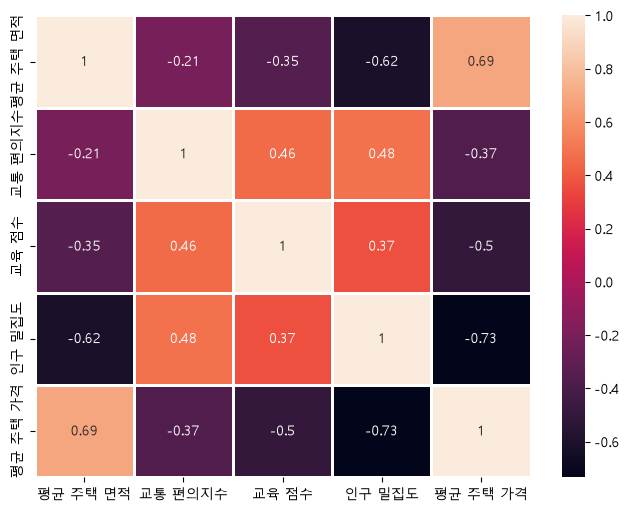

In [107]:
# 데이터 분포 확인 - 변수 간 상관관계(히트맵)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), linewidths=1, annot=True)

'''
히트맵의 우측에 표시된 컬러바의 수치에 따르면 색상이 밝을수록 양의 상관관계가 높은 값이고, 어두운 색일수록 음의 상관관계가 높은 변수이다.
'''

In [108]:
'''
문6-14> '평균 주택 가격'과 가장 상관관계가 높은 특성을 순서대로 출력하시오.
'''
np.abs(df.corr()['평균 주택 가격']).sort_values(ascending=False)

평균 주택 가격    1.000000
인구 밀집도      0.734713
평균 주택 면적    0.694622
교육 점수       0.500726
교통 편의지수     0.374742
Name: 평균 주택 가격, dtype: float64

In [109]:
'''
문6-15> '주어진 데이터 프레임의 결측치와 중복값이 있는지 확인하고, 있을 경우 삭제하시오.
'''
# 결측치 확인
df.isna().sum()

평균 주택 면적    0
교통 편의지수     0
교육 점수       0
인구 밀집도      0
평균 주택 가격    0
dtype: int64

In [110]:
# 중복값 확인
df.duplicated().sum()

np.int64(0)

In [111]:
'''
문6-16> 주어진 데이터를 독립변수(X)와 종속변수(y)로 할당하시오.
- 독립변수(X): '평균 주택 가격'을 제외한 모든 속성
- 종속변수(y): '평균 주택 가격'
'''
X = df.drop('평균 주택 가격', axis=1, inplace=False)
y = df['평균 주택 가격']
print(X)
print(y)

     평균 주택 면적  교통 편의지수      교육 점수     인구 밀집도
0      83.910     16.0  67.021277  31.346578
1      88.920     24.0  55.319149  38.714128
2      95.925     96.0  80.851064  31.843267
3     100.170     16.0  36.170213  12.527594
4      92.430      8.0  22.340426  15.728477
..        ...      ...        ...        ...
495    88.065     96.0  80.851064  32.036424
496   130.560     20.0   4.255319   9.354305
497    82.800     96.0  80.851064  62.996689
498   123.885     28.0  69.148936   4.994481
499    90.705     16.0  89.361702  42.908389

[500 rows x 4 columns]
0       34.8
1       36.6
2       43.4
3       57.2
4       48.2
       ...  
495     41.2
496    100.0
497     24.6
498     85.6
499     29.6
Name: 평균 주택 가격, Length: 500, dtype: float64


In [112]:
'''
문6-17> 문6-16의 독립변수(X)의 데이터의 분포를 평균은 0, 표준편차는 1이 되도록 변환한 값을 X_scaled로 할당하시오.
'''
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.97959808, -0.63375919,  0.20781835,  0.06374933],
       [-0.50397931, -0.40304962, -0.30063402,  0.43940747],
       [ 0.16103255,  1.6733365 ,  0.80871661,  0.0890746 ],
       ...,
       [-1.08497469,  1.6733365 ,  0.80871661,  1.6775317 ],
       [ 2.81538398, -0.28769483,  0.30026424, -1.27989685],
       [-0.33452233, -0.63375919,  1.17850016,  0.6532653 ]],
      shape=(500, 4))

In [113]:
'''
문6-18> 전처리가 완료된 데이터(X_scaled, y)를 학습용과 테스트용 데이터로 분할하시오.
- 학습용 데이터와 테스트용 데이터의 비율은 7:3
'''
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(350, 4) (150, 4) (350,) (150,)


In [114]:
'''
문6-19> 학습용 데이터를 사용하여 선형 회귀 모델을 학습하고, 가중치와 편향을 출력하시오.
'''
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('weight:', lr_model.coef_)
print('bias:', lr_model.intercept_)

weight: [ 8.37360226 -0.68007229 -3.48014443 -6.39361632]
bias: 44.97676980530395


In [115]:
'''
문6-20> 학습된 선형 회귀 모델의 가중치가 가장 높은 변수가 무엇인지 확인하시오.
'''
coef = pd.Series(data=np.round(lr_model.coef_, 1), index=X.columns)
coef

평균 주택 면적    8.4
교통 편의지수    -0.7
교육 점수      -3.5
인구 밀집도     -6.4
dtype: float64

"\n'평균 주택 면적'과 '인구 밀집도'가 '평균 주택 가격'을 예측하는데 가장 가중치가 높은 속성이다.\n"

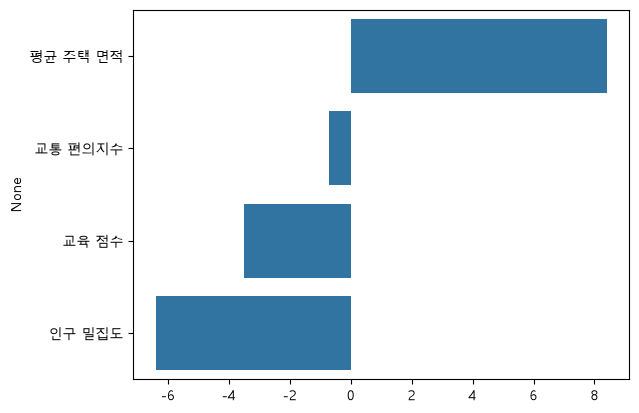

In [116]:
# 각 속성의 가중치를 좀 더 직관적으로 확인해보기 위해 막대그래프(barplot)으로 시각화한다.
coef_sort = coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values, y=coef_sort.index)

'''
'평균 주택 면적'과 '인구 밀집도'가 '평균 주택 가격'을 예측하는데 가장 가중치가 높은 속성이다.
'''

In [117]:
'''
문6-21> 문6-19의 선형 회귀 모델의 성능 지표(MSE, RMSE, R-sqaure)를 출력하시오.
'''
def printRegressorResult(y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print('MSE : {0:.3f} , RMSE : {1:.3f}, r2 : {2:.3f}'.format(mse , rmse, r2))

y_pred = lr_model.predict(X_test)
printRegressorResult(y_test, y_pred)

MSE : 138.472 , RMSE : 11.767, r2 : 0.560


In [118]:
'''
문6-22> 선형 회귀 모델의 일반화 성능을 평가하기 위해 교차 검증을 수행하고, 결과를 출력하시오.
- 선형 회귀 모델: 문6-19에서 생성한 모델
- 3등분하여 학습용과 검증용의 역할을 번갈아가면서 수행
- return_train_score=True, return_estimator=True, scoring="neg_mean_squared_error"
'''
# cv: 3개의 train, test set fold로 나누어 학습
scores = cross_validate(lr_model, X, y, scoring="neg_mean_squared_error", cv=3, return_train_score=True, return_estimator=True)

print('Scores', scores)

Scores {'fit_time': array([0.00595379, 0.00396824, 0.00399637]), 'score_time': array([0.00545549, 0.00396895, 0.00148773]), 'estimator': [LinearRegression(), LinearRegression(), LinearRegression()], 'test_score': array([ -82.86260072, -114.98382233, -140.51093041]), 'train_score': array([-123.03384583, -106.65114853,  -92.74886566])}


In [ ]:
""" 
Scores {
    'fit_time': array([0.00595379, 0.00396824, 0.00399637]), 
    'score_time': array([0.00545549, 0.00396895, 0.00148773]),
    'estimator': [LinearRegression(), LinearRegression(), LinearRegression()],
    'test_score': array([ -82.86260072, -114.98382233, -140.51093041]),
    'train_score': array([-123.03384583, -106.65114853,  -92.74886566])
}
"""
'''
회귀 모델에서 일반적으로 사용하는 평가 지표인 MSE(Mean Squared Error)는 값이 작으면 작을수록 성능이 더 좋은 모델이다. cross_validate() 함수에서 사용하는 score는 점수가 크면 클수록 좋은 모델이라고 판단하기 때문에 MSE값에 음수값을 취한 'neg_mean_squared_error'를 모델의 성능 지표로 사용한다.
'''

"\n회귀 모델에서 일반적으로 사용하는 평가 지표인 MSE(Mean Squared Error)는 값이 작으면 작을수록 성능이 더 좋은 모델이다. cross_validate() 함수에서 사용하는 score는 점수가 크면 클수록 좋은 모델이라고 판단하기 때문에 MSE값에 음수값을 취한 'neg_mean_squared_error'를 모델의 성능 지표로 사용한다.\n"

In [120]:
'''
문6-23> 테스트셋에 대해 실제값(y)과 예측값(y_pred)의 차이를 확인하기 위해 아래 조건을 만족하는 데이터 프레임(result)를 생성하시오.
- 행: 실제값(y), 예측값(y_pred), 실제값과 예측값의 차이(diff)
- 'diff' 컬럼을 기준으로 값이 큰 순서대로 정렬하여 상위 5개의 값만 출력
'''
result = pd.DataFrame({
    'y': y_test.values,
    'y_pred': y_pred,
    'diff': np.abs(y_test.values - y_pred)
})
result.sort_values(by=['diff'], ascending=False).head()

,y,y_pred,diff
76,100.0,33.815985,66.184015
149,100.0,43.033172,56.966828
43,55.0,13.542672,41.457328
12,27.6,-7.328432,34.928432
109,46.2,11.557502,34.642498
